# **Leveraging Convolutional Neural Networks for Multi-Dimensional Classification of Nutritional Status Using Anthropometric Indicators in Child Health**


In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, MaxPooling1D
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [39]:
import pandas as pd

file_path = "/Users/mac/Documents/RESEARCH WORK/Machine learning origianl.xlsx"
data = pd.read_excel(file_path)

# Display the first few rows to ensure it's loaded correctly
print(data.head())


  SEX_CHILD  Religion:  SEX_HH_HEAD  AGE_MOTHER  HH_SIZE Place of residence  \
0    Female          1            2          25        3              Rural   
1      Male          1            2          20        4              Rural   
2    Female          2            2          35        5              Rural   
3      Male          1            2          21        3              Rural   
4    Female          2            1          35        4              Rural   

  Ethnicity  AGE_CHILD_DAYS  WT_CHILD_KG  Height_Child__CM  HT_CHILD_Metre  \
0    Yoruba          1380.0          5.3             73.00          0.7300   
1    Yoruba          1470.0         11.8             86.01          0.8601   
2    Yoruba          1110.0          9.6            100.80          1.0080   
3    Yoruba           270.0          6.2             66.60          0.6660   
4    Yoruba           330.0          8.1             67.00          0.6700   

   HT_CHILD_Metre^2  Weight_Mother_KG  Height_Mother_CM 

In [40]:
data.dtypes
 

SEX_CHILD                 object
Religion:                  int64
SEX_HH_HEAD                int64
AGE_MOTHER                 int64
HH_SIZE                    int64
Place of residence        object
Ethnicity                 object
AGE_CHILD_DAYS           float64
WT_CHILD_KG              float64
Height_Child__CM         float64
HT_CHILD_Metre           float64
HT_CHILD_Metre^2         float64
Weight_Mother_KG         float64
Height_Mother_CM         float64
Height_Mother_Metre      float64
Height_Mother_Metre^2    float64
BMI_CHILD                float64
BMI_MOTHER               float64
dtype: object

In [41]:

df = data.dropna()  

In [42]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['SEX_CHILD'] = encoder.fit_transform(df['SEX_CHILD'])
df['Place of residence'] = encoder.fit_transform(df['Place of residence'])
df['Ethnicity'] = encoder.fit_transform(df['Ethnicity'])



In [43]:
# Define nutritional status categories based on BMI
def classify_bmi(bmi):
    if bmi < 18.5:
        return 0  # Underweight
    elif 18.5 <= bmi < 24.9:
        return 1  # Normal weight
    elif 25 <= bmi < 29.9:
        return 2  # Overweight
    else:
        return 3  # Obese

df['Nutritional_Status'] = df['BMI_CHILD'].apply(classify_bmi)


print(df['Nutritional_Status'].value_counts())


Nutritional_Status
0    679
1     46
3     22
2      5
Name: count, dtype: int64


In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

X = df.drop(columns=['Nutritional_Status'])  # Ensure 'Nutritional_Status' exists
y = df['Nutritional_Status']

# Standardize feature variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

print(feature_importances)


                  Feature  Importance
16              BMI_CHILD    0.509119
10         HT_CHILD_Metre    0.101052
8             WT_CHILD_KG    0.091538
11       HT_CHILD_Metre^2    0.082984
9        Height_Child__CM    0.075474
12       Weight_Mother_KG    0.025467
17             BMI_MOTHER    0.025236
7          AGE_CHILD_DAYS    0.021447
14    Height_Mother_Metre    0.013512
15  Height_Mother_Metre^2    0.013389
13       Height_Mother_CM    0.011834
3              AGE_MOTHER    0.011320
4                 HH_SIZE    0.008433
0               SEX_CHILD    0.004904
1               Religion:    0.003848
2             SEX_HH_HEAD    0.000253
5      Place of residence    0.000190
6               Ethnicity    0.000000


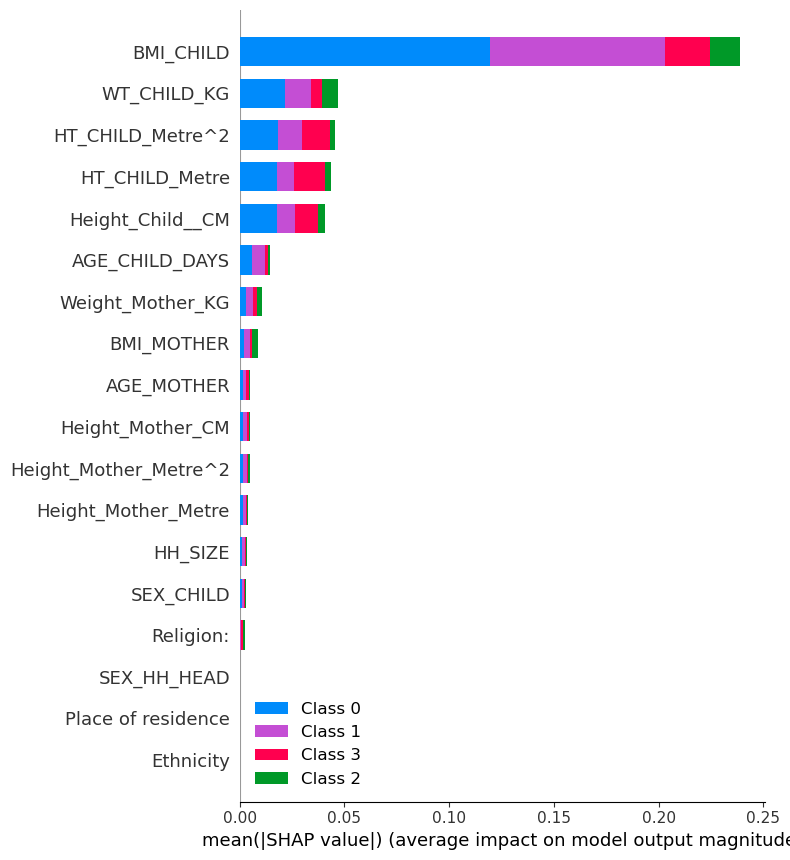

In [45]:
import shap


explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


In [46]:
X = df.drop(columns=['Nutritional_Status'])
y = df['Nutritional_Status']

In [47]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [48]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Scale the features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [49]:
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

model = Sequential()
model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(len(y.unique()), activation='softmax'))


model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [50]:
from tensorflow.keras.utils import to_categorical

y_train_encoded = to_categorical(y_train)
y_test_encoded = to_categorical(y_test)

# Model architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

model = Sequential()
model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(y_train_encoded.shape[1], activation='softmax'))  # Updated for correct output size

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [51]:
history = model.fit(X_train_reshaped, y_train_encoded, epochs=20, batch_size=32, validation_split=0.2, verbose=1)


Epoch 1/20
15/15 [==============================] - 1s 20ms/step - loss: 0.7055 - accuracy: 0.8250 - val_loss: 0.4378 - val_accuracy: 0.9091
Epoch 2/20
15/15 [==============================] - 0s 6ms/step - loss: 0.3797 - accuracy: 0.9083 - val_loss: 0.3118 - val_accuracy: 0.9174
Epoch 3/20
15/15 [==============================] - 0s 5ms/step - loss: 0.2799 - accuracy: 0.9271 - val_loss: 0.2686 - val_accuracy: 0.9256
Epoch 4/20
15/15 [==============================] - 0s 4ms/step - loss: 0.2557 - accuracy: 0.9312 - val_loss: 0.2445 - val_accuracy: 0.9256
Epoch 5/20
15/15 [==============================] - 0s 4ms/step - loss: 0.2367 - accuracy: 0.9312 - val_loss: 0.2283 - val_accuracy: 0.9256
Epoch 6/20
15/15 [==============================] - 0s 4ms/step - loss: 0.2221 - accuracy: 0.9312 - val_loss: 0.2154 - val_accuracy: 0.9339
Epoch 7/20
15/15 [==============================] - 0s 4ms/step - loss: 0.2149 - accuracy: 0.9312 - val_loss: 0.2052 - val_accuracy: 0.9339
Epoch 8/20
15/15 [=

5/5 [==============================] - 0s 2ms/step - loss: 0.2414 - accuracy: 0.9404
Test Loss: 0.24136918783187866
Test Accuracy: 0.940397322177887


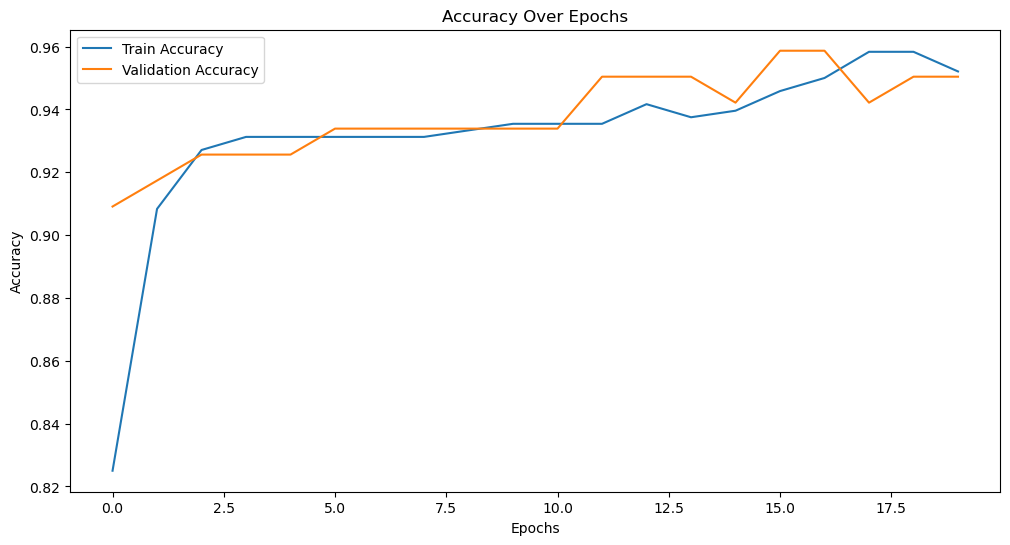

In [52]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(X_test_reshaped, y_test_encoded, verbose=1)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [53]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from keras.optimizers import Adam
from keras_tuner import HyperParameters

def build_model(hp):
    model = Sequential()
    model.add(Conv1D(
        filters=hp.Int('filters', min_value=32, max_value=128, step=32),
        kernel_size=hp.Choice('kernel_size', values=[2, 3, 5]),
        activation='relu',
        input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])
    ))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(
        units=hp.Int('units', min_value=32, max_value=256, step=32),
        activation='relu'
    ))
    model.add(Dropout(hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(Dense(len(y_train_encoded[0]), activation='softmax'))
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice('learning_rate', values=[1e-3, 1e-4, 1e-5])),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [54]:
from keras_tuner import RandomSearch

tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,  # Number of different hyperparameter combinations to try
    executions_per_trial=3,  # Average over 3 runs
    directory='my_dir',  # Where results are saved
    project_name='cnn_hyperparam_tuning'
)

tuner.search(
    X_train_reshaped, y_train_encoded,
    epochs=10,
    validation_data=(X_test_reshaped, y_test_encoded)
)


Reloading Tuner from my_dir/cnn_hyperparam_tuning/tuner0.json


In [55]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Optimal Hyperparameters:
- Filters: {best_hps.get('filters')}
- Kernel Size: {best_hps.get('kernel_size')}
- Dense Units: {best_hps.get('units')}
- Dropout Rate: {best_hps.get('dropout_rate')}
- Learning Rate: {best_hps.get('learning_rate')}
""")



Optimal Hyperparameters:
- Filters: 128
- Kernel Size: 5
- Dense Units: 256
- Dropout Rate: 0.1
- Learning Rate: 0.001



In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Conv1D(128, 5, activation='relu', input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])),
    MaxPooling1D(pool_size=2),
    Dropout(0.1),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.1),
    Dense(y_train_encoded.shape[1], activation='softmax')
])
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train_reshaped, y_train_encoded,
    epochs=20,
    validation_data=(X_test_reshaped, y_test_encoded)
)


Epoch 1/20
19/19 [==============================] - 1s 32ms/step - loss: 0.6400 - accuracy: 0.8619 - val_loss: 0.6967 - val_accuracy: 0.8808
Epoch 2/20
19/19 [==============================] - 0s 7ms/step - loss: 0.3330 - accuracy: 0.9218 - val_loss: 0.4139 - val_accuracy: 0.9073
Epoch 3/20
19/19 [==============================] - 0s 6ms/step - loss: 0.2597 - accuracy: 0.9301 - val_loss: 0.3823 - val_accuracy: 0.9073
Epoch 4/20
19/19 [==============================] - 0s 20ms/step - loss: 0.2195 - accuracy: 0.9318 - val_loss: 0.3493 - val_accuracy: 0.9073
Epoch 5/20
19/19 [==============================] - 0s 19ms/step - loss: 0.2124 - accuracy: 0.9318 - val_loss: 0.3477 - val_accuracy: 0.9073
Epoch 6/20
19/19 [==============================] - 0s 11ms/step - loss: 0.1778 - accuracy: 0.9401 - val_loss: 0.3132 - val_accuracy: 0.9073
Epoch 7/20
19/19 [==============================] - 0s 7ms/step - loss: 0.1649 - accuracy: 0.9368 - val_loss: 0.2961 - val_accuracy: 0.9073
Epoch 8/20
19/19

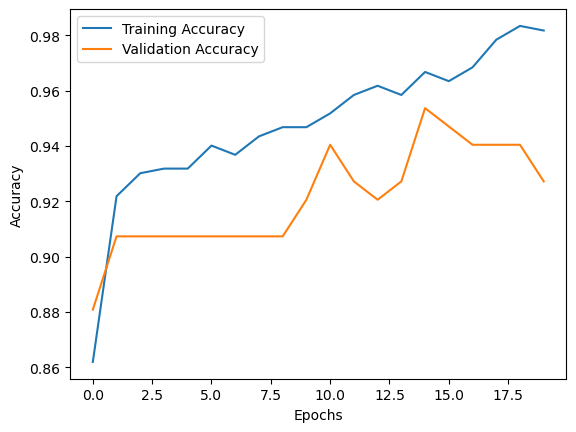

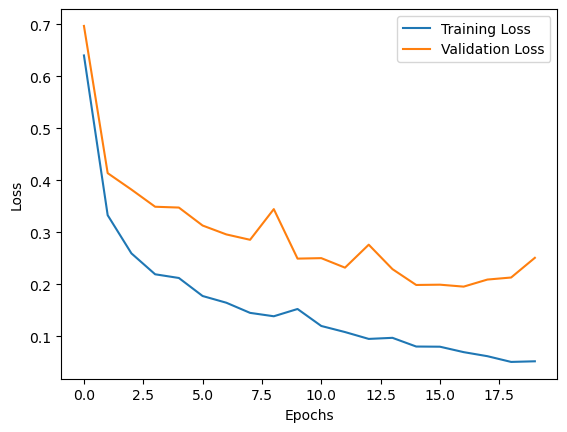

In [57]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9735099337748344
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       133
           1       0.90      0.75      0.82        12
           2       0.00      0.00      0.00         1
           3       1.00      1.00      1.00         5

    accuracy                           0.97       151
   macro avg       0.72      0.69      0.70       151
weighted avg       0.98      0.97      0.98       151



In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler

# Normalize the dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for CNN input (samples, time steps, features)
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Convert labels to categorical (one-hot encoding)
y_train_encoded = to_categorical(y_train)
y_test_encoded = to_categorical(y_test)

# Build 1D-CNN model
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train_reshaped.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(y_train_encoded.shape[1], activation='softmax'))  # Output layer

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
model.fit(X_train_reshaped, y_train_encoded, epochs=10, batch_size=32, validation_data=(X_test_reshaped, y_test_encoded))

# Predictions
y_pred_cnn = model.predict(X_test_reshaped)
y_pred_cnn_classes = y_pred_cnn.argmax(axis=1)  # Convert one-hot to class labels

# Evaluation
print("1D-CNN Accuracy:", accuracy_score(y_test, y_pred_cnn_classes))
print("Classification Report:\n", classification_report(y_test, y_pred_cnn_classes))


Epoch 1/10
19/19 [==============================] - 2s 13ms/step - loss: 0.6560 - accuracy: 0.8636 - val_loss: 0.5809 - val_accuracy: 0.8808
Epoch 2/10
19/19 [==============================] - 0s 5ms/step - loss: 0.3532 - accuracy: 0.9135 - val_loss: 0.3863 - val_accuracy: 0.9073
Epoch 3/10
19/19 [==============================] - 0s 6ms/step - loss: 0.2737 - accuracy: 0.9301 - val_loss: 0.3679 - val_accuracy: 0.9073
Epoch 4/10
19/19 [==============================] - 0s 5ms/step - loss: 0.2479 - accuracy: 0.9318 - val_loss: 0.3793 - val_accuracy: 0.9073
Epoch 5/10
19/19 [==============================] - 0s 5ms/step - loss: 0.2229 - accuracy: 0.9318 - val_loss: 0.3482 - val_accuracy: 0.9073
Epoch 6/10
19/19 [==============================] - 0s 5ms/step - loss: 0.2147 - accuracy: 0.9334 - val_loss: 0.3588 - val_accuracy: 0.9073
Epoch 7/10
19/19 [==============================] - 0s 5ms/step - loss: 0.2019 - accuracy: 0.9334 - val_loss: 0.3331 - val_accuracy: 0.9073
Epoch 8/10
19/19 [=

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
